In [1]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv("movie_revenue.csv")

df.head()

,Unnamed: 0,title,year,runtime,rating,revenue
0,0,Avatar,(2009),162 mins.,7.9,$761M
1,1,Titanic,(1997),194 mins.,7.7,$659M
2,2,The Avengers,(2012),143 mins.,8.2,$623M
3,3,The Dark Knight,(2008),152 mins.,9.0,$533M
4,4,Star Wars: Episode I - The Phantom Menace,(1999),136 mins.,6.6,$475M


In [3]:
# =========================
# 3. Basic Info
# =========================
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 6560 entries, 0 to 6559
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  6560 non-null   int64  
 1   title       6560 non-null   str    
 2   year        6560 non-null   str    
 3   runtime     6539 non-null   str    
 4   rating      6560 non-null   float64
 5   revenue     6560 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 535.2 KB
None
        Unnamed: 0       rating
count  6560.000000  6560.000000
mean   3279.500000     6.835610
std    1893.853215     1.109706
min       0.000000     1.600000
25%    1639.750000     6.200000
50%    3279.500000     6.900000
75%    4919.250000     7.600000
max    6559.000000     9.900000
Unnamed: 0     0
title          0
year           0
runtime       21
rating         0
revenue        0
dtype: int64


In [5]:
df = df.fillna(df.median(numeric_only=True))

df[df.select_dtypes(include=['object', 'string']).columns] = \
    df.select_dtypes(include=['object', 'string']).fillna("missing")

In [6]:
# =========================
# 5. Define Features & Target
# =========================

# CHANGE 'revenue' if your dataset uses a different name
X = df.drop("revenue", axis=1)
y = df["revenue"]

In [7]:
# =========================
# 6. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# =========================
# 7. Decision Tree Regressor
# =========================
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [9]:
# =========================
# 8. Decision Tree Evaluation
# =========================
print("Decision Tree Results:")
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score:", r2_score(y_test, dt_pred))

Decision Tree Results:
MAE: 4.505335365853658
RMSE: 53.27552205281521
R2 Score: 0.9946264894682357


In [10]:
# =========================
# 9. Random Forest Regressor
# =========================
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [11]:
# =========================
# 10. Random Forest Evaluation
# =========================
print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results:
MAE: 5.752888719512196
RMSE: 45.65022237760732
R2 Score: 0.9960546233393232


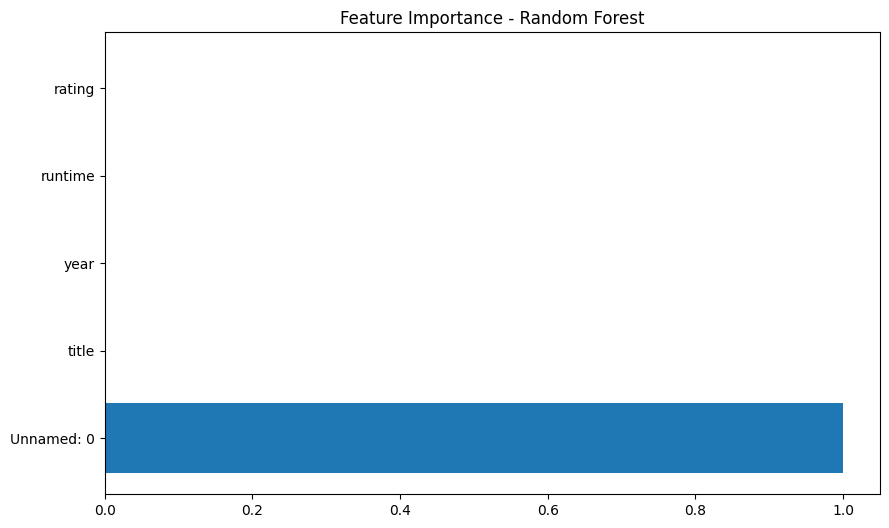

In [12]:
# =========================
# 11. Feature Importance Plot
# =========================
importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance - Random Forest")
plt.show()